In [22]:
import matplotlib.pyplot as plt
import pandas as pd

In [23]:


df = pd.read_csv("../data/ventes.csv")

df

,Date,Produit,Categorie,Prix,Quantite,Ville
0,2025-01-05,Ordinateur,Informatique,2500,1,Tunis
1,2025-01-08,Souris,Accessoire,50,3,Sfax
2,2025-01-12,Clavier,Accessoire,120,2,Tunis
3,2025-01-18,Ecran,Informatique,800,1,Sousse
4,2025-02-03,Ordinateur,Informatique,2500,2,Sousse
5,2025-02-10,Souris,Accessoire,50,5,Tunis
6,2025-02-15,Clavier,Accessoire,120,3,Sfax
7,2025-02-22,Ecran,Informatique,800,2,Tunis
8,2025-03-02,Ordinateur,Informatique,2500,1,Sfax
9,2025-03-09,Souris,Accessoire,50,4,Sousse


In [24]:
df.shape

(16, 6)

In [25]:
df.columns

Index(['Date', 'Produit', 'Categorie', 'Prix', 'Quantite', 'Ville'], dtype='str')

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Date       16 non-null     str  
 1   Produit    16 non-null     str  
 2   Categorie  16 non-null     str  
 3   Prix       16 non-null     int64
 4   Quantite   16 non-null     int64
 5   Ville      16 non-null     str  
dtypes: int64(2), str(4)
memory usage: 900.0 bytes


In [27]:
df.describe()

,Prix,Quantite
count,16.000000,16.000000
mean,867.500000,2.875000
std,1019.369086,1.543805
min,50.000000,1.000000
25%,102.500000,2.000000
50%,460.000000,2.500000
75%,1225.000000,4.000000
max,2500.000000,6.000000


In [28]:
total_produits = df["Quantite"].sum()

print("Nombre total de produits vendus :", total_produits)

Nombre total de produits vendus : 46


In [29]:
df["Chiffre_Affaires"] =df["Prix"]*df["Quantite"]
print(df)

          Date     Produit     Categorie  Prix  Quantite   Ville  \
0   2025-01-05  Ordinateur  Informatique  2500         1   Tunis   
1   2025-01-08      Souris    Accessoire    50         3    Sfax   
2   2025-01-12     Clavier    Accessoire   120         2   Tunis   
3   2025-01-18       Ecran  Informatique   800         1  Sousse   
4   2025-02-03  Ordinateur  Informatique  2500         2  Sousse   
5   2025-02-10      Souris    Accessoire    50         5   Tunis   
6   2025-02-15     Clavier    Accessoire   120         3    Sfax   
7   2025-02-22       Ecran  Informatique   800         2   Tunis   
8   2025-03-02  Ordinateur  Informatique  2500         1    Sfax   
9   2025-03-09      Souris    Accessoire    50         4  Sousse   
10  2025-03-14     Clavier    Accessoire   120         5   Tunis   
11  2025-03-25       Ecran  Informatique   800         3    Sfax   
12  2025-04-04  Ordinateur  Informatique  2500         2   Tunis   
13  2025-04-11      Souris    Accessoire    50  

In [30]:
chiffre_affaires_total = df["Chiffre_Affaires"].sum()

print("Chiffre d'affaires total :", chiffre_affaires_total)

Chiffre d'affaires total : 23980


In [31]:
ca_produit = df.groupby("Produit")["Chiffre_Affaires"].sum()

print(ca_produit)

Produit
Clavier        1680
Ecran          6400
Ordinateur    15000
Souris          900
Name: Chiffre_Affaires, dtype: int64


In [32]:
ca_categorie = df.groupby("Categorie")["Chiffre_Affaires"].sum()

print(ca_categorie)

Categorie
Accessoire       2580
Informatique    21400
Name: Chiffre_Affaires, dtype: int64


In [33]:
quantite_produit = df.groupby("Produit")["Quantite"].sum()

print(quantite_produit)

Produit
Clavier       14
Ecran          8
Ordinateur     6
Souris        18
Name: Quantite, dtype: int64


In [34]:
ca_ville = df.groupby("Ville")["Chiffre_Affaires"].sum()

print(ca_ville)

Ville
Sfax       5710
Sousse     6480
Tunis     11790
Name: Chiffre_Affaires, dtype: int64


In [35]:
df["Date"] = pd.to_datetime(df["Date"])


In [36]:
df["Date"].dtype

dtype('<M8[us]')

In [37]:
df["Mois"] = df["Date"].dt.month

In [38]:
df[["Date", "Mois"]]

,Date,Mois
0,2025-01-05,1
1,2025-01-08,1
2,2025-01-12,1
3,2025-01-18,1
4,2025-02-03,2
5,2025-02-10,2
6,2025-02-15,2
7,2025-02-22,2
8,2025-03-02,3
9,2025-03-09,3


In [39]:
ca_mois = df.groupby("Mois")["Chiffre_Affaires"].sum()
print(ca_mois)

Mois
1    3690
2    7210
3    5700
4    7380
Name: Chiffre_Affaires, dtype: int64


In [40]:
ventes_mois_produit = df.groupby(["Mois", "Produit"])["Quantite"].sum()
print(ventes_mois_produit)

Mois  Produit   
1     Clavier       2
      Ecran         1
      Ordinateur    1
      Souris        3
2     Clavier       3
      Ecran         2
      Ordinateur    2
      Souris        5
3     Clavier       5
      Ecran         3
      Ordinateur    1
      Souris        4
4     Clavier       4
      Ecran         2
      Ordinateur    2
      Souris        6
Name: Quantite, dtype: int64


In [41]:
df["Chiffre_Affaires"].mean()

np.float64(1498.75)

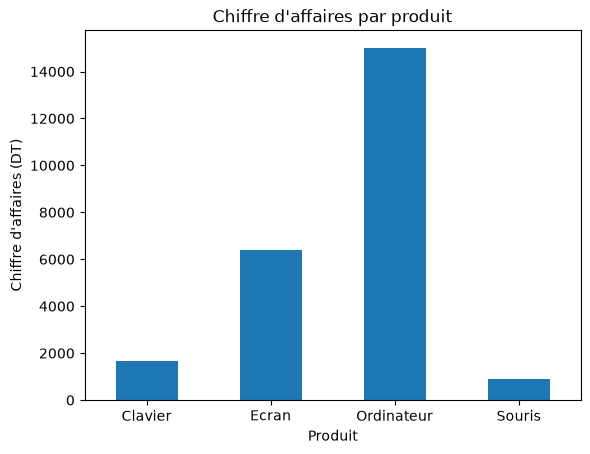

In [42]:
ca_produit = df.groupby("Produit")["Chiffre_Affaires"].sum()

ca_produit.plot(kind="bar")

plt.title("Chiffre d'affaires par produit")
plt.xlabel("Produit")
plt.ylabel("Chiffre d'affaires (DT)")
plt.xticks(rotation=0)
plt.show()

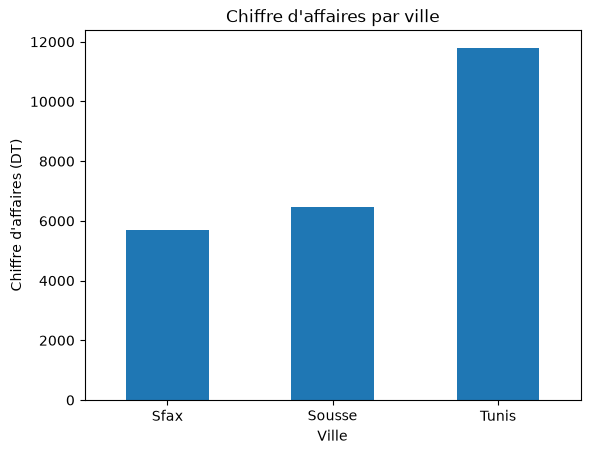

In [43]:
ca_ville = df.groupby("Ville")["Chiffre_Affaires"].sum()

ca_ville.plot(kind="bar")

plt.title("Chiffre d'affaires par ville")
plt.xlabel("Ville")
plt.ylabel("Chiffre d'affaires (DT)")
plt.xticks(rotation=0)
plt.show()

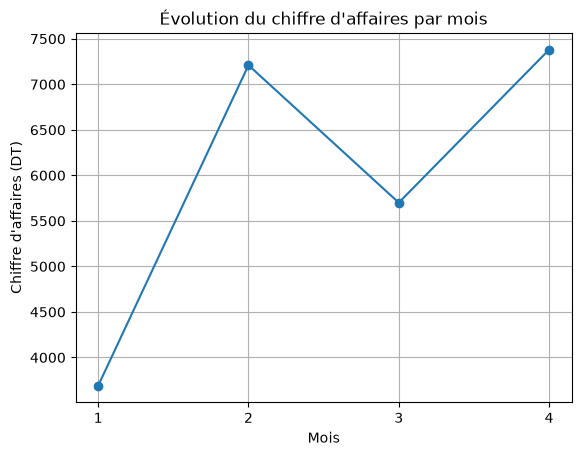

In [44]:
ca_mois = df.groupby("Mois")["Chiffre_Affaires"].sum()

ca_mois.plot(kind="line", marker="o")

plt.title("Évolution du chiffre d'affaires par mois")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (DT)")
plt.xticks([1, 2, 3, 4])
plt.grid()
plt.show()

## 6. Conclusions de l'analyse

### Principales observations

– Le chiffre d'affaires total réalisé est de 23 980 DT.
– L'ordinateur est le produit qui génère le plus de chiffre d'affaires avec 15 000 DT.
– La catégorie Informatique représente la plus grande partie du chiffre d'affaires avec 21 400 DT.
– La souris est le produit le plus vendu en quantité avec 18 unités.
– Tunis est la ville qui génère le plus de chiffre d'affaires avec 11 790 DT.
– Avril est le mois le plus performant avec un chiffre d'affaires de 7 380 DT.

### Conclusion générale

L'analyse montre que les produits informatiques, notamment les ordinateurs, représentent la principale source de chiffre d'affaires. Tunis est la ville la plus performante et avril est le mois avec le meilleur chiffre d'affaires. En revanche, la souris est le produit le plus vendu en quantité, malgré un chiffre d'affaires relativement faible.